# White dwarf star structure

We'll investigate white dwarg structure by consider integrating the equation of  hydrostatic equilibrium:

$$\frac{dP}{dr} = - \frac{G M(r)}{r^2}$$

together with continuity:

$$\frac{dM}{dr} = 4\pi r^2 \rho$$

and we'll use the zero-T degenerate equation of state.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

First we'll write our RHS function.  We'll integrate

$${\bf Y} = \left ( \begin{array}{c} m \\ P \end{array} \right )$$

All of our units will be in CGS.

Some physical constants (CGS)

In [74]:
G = 6.67e-8
c = 3.e10
h = 6.63e-27
m_u = 1.66e-24
m_e = 9.11e-28
M_sun = 2.e33

Here's the righthand side function:

In [57]:
def rhs_newton(r, y, rho_func, P_c):
    m, P = y

    rho = rho_func(P)
    
    dmdr = 4.0 * np.pi * r**2 * rho
    
    if r == 0.0:
        dPdr = 0.0
    else:
        dPdr = -G * m / r**2 * rho
        
    return np.array([dmdr, dPdr])

Now, we have our EOS as $P(\rho)$, but we need to invert it, $\rho(P)$.  For this
we'll use a root finding algorithm.

## Degenerate neutrons

For zero-T neutron degeneracy, the number density of electrons is

$$n_e = \frac{\rho Y_e}{m_u} = \frac{8\pi}{3h^3} p_F^3 = \frac{8\pi}{3} \left (\frac{m_e c}{h} \right )^3 x_F^3$$

where $x_F = p_F / (m_e c)$.

We'll write this as 

$$\rho = B x_F^3$$

and the pressure is

$$P = \frac{\pi}{3} \left ( \frac{m_e c}{h} \right )^3 m_e c^2 f(x)$$

with

$$f(x) = x (2x^2 - 3) (1 + x^2)^{1/2} + 3 \sinh^{-1}(x)$$

In [17]:
from scipy.optimize import brentq
import numpy as np

In [64]:
def pres_deg(rho, Y_e=0.5):
    # compute the dimensionless Fermi momentum x = p / mc
    # from rho
    B = 8 * np.pi * m_u / 3.0 * (m_e * c / h)**3 / Y_e
    x = np.cbrt(rho / B)

    # compute the dimensionless pressure
    f = x * (2 * x**2 - 3) * np.sqrt(1 + x**2) + 3 * np.arcsinh(x)

    # compute the pressure scaling
    A = (np.pi / 3) * (m_e * c / h)**3 * m_e * c**2
    
    return A * f
    
def rho_deg(pres, Y_e=0.5):

    # we shouldn't encounter this
    if pres < 0:
        return 0;
        
    A = (np.pi / 3) * (m_e * c / h)**3 * m_e * c**2
    f = pres / A
    
    # find the x that gives us this f
    x = brentq(lambda x: f - (x * (2 * x**2 - 3) *
                              np.sqrt(1 + x**2) + 3 * np.arcsinh(x)),
               0, 1000)
    
    B = 8 * np.pi * m_u / 3.0 * (m_e * c / h)**3 / Y_e
    return B * x**3 

Now integrate

In [65]:
from scipy.integrate import solve_ivp

we'll use an event to stop the integration

In [66]:
def surface(t, y, rho_func, P_c):
    # return the pressure -- when it is zero we will terminate
    smallp = P_c / 1.e10
    return y[1] - smallp
surface.terminal = True
surface.direction = -1

we'll pick a large ending radius, since we'll terminate before we end

In [67]:
R_sun = 7.e10
r_end = R_sun

We need initial conditions.  We'll supply the central density and get the pressure from that.  The initial mass ($m(r=0)$) is 0.

In [68]:
rho_c = 2.e9
P_c = pres_deg(rho_c)
P_c

np.float64(1.2338331610469019e+27)

now we can integrate

In [69]:
sol = solve_ivp(rhs_newton, (0, r_end), np.array([0.0, P_c]), args=(rho_deg, P_c),
                events=surface)

In [70]:
sol

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  1.000e-04 ...  2.054e+08  2.055e+08]
        y: [[ 0.000e+00  8.378e-03 ...  2.776e+33  2.776e+33]
            [ 1.234e+27  1.234e+27 ...  3.046e+17  1.234e+17]]
      sol: None
 t_events: [array([ 2.055e+08])]
 y_events: [array([[ 2.776e+33,  1.234e+17]])]
     nfev: 338
     njev: 0
      nlu: 0

now do a grid

In [94]:
rhocs = np.logspace(7, 11, 30)

mass = []
radius = []
for rho_c in rhocs:
    P_c = pres_deg(rho_c)
    sol = solve_ivp(rhs_newton, (0, r_end), np.array([0.0, P_c]),
                    rtol=1.e-5, atol=1.e-10,
                    args=(rho_deg, P_c), events=surface)
    assert sol.success
    mass.append(sol.y[0, -1])
    radius.append(sol.t[-1])
    

In [95]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'radius ($R_\\odot$)')

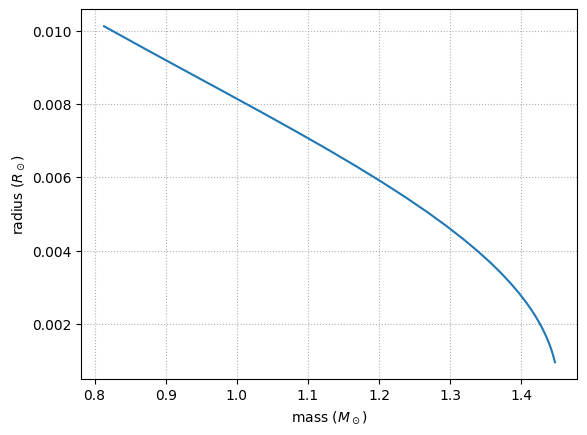

In [96]:
fig, ax = plt.subplots()

ax.plot(np.array(mass) / M_sun, np.array(radius) / R_sun)
ax.grid(ls=":")
ax.set_xlabel(r"mass ($M_\odot$)")
ax.set_ylabel(r"radius ($R_\odot$)")